# Exploratory Data Analysis (EDA)

## Structure and missing values

Checking shapes, column types and missing values

In [1]:
import pandas as pd
import seaborn as sns
from features import *
import matplotlib.pyplot as plt

data = pd.read_csv("train.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [2]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [4]:
data.shape

(1460, 81)

In [5]:
data.isna().sum() / len(data) * 100

Id                0.000000
MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64

## Missing Values:

 - `PoolQC` NA converted to False (no pool), any quality values (Ex, Gd, TA, Fa) converted to True (HasPool)
 - `MiscFeature` Rejected - all its information is captured more completely by `MiscVal`. (0 = no additional feature, i.e. the numeric equivalent of `MiscFeature`'s NaN)
 - `Alley` NA converted to 'NoAlley', then one-hot encoded
 - `Fence` NA converted to 'NoFence', then one-hot encoded
 - `MasVnrType` NA converted to 'NoMasonryVeneer', then one-hot encoded
 - `FireplaceQu` Manually mapped to ordinal values (0=None, 1=Po, 2=Fa, 3=TA, 4=Gd, 5=Ex)
 - `LotFrontage` Due to significant disparity in results across neighborhoods (from 21 to 91) - NaN values were replaced with the median `LotFrontage` of the respective neighborhood, not global median
 - `GarageQual` Manually mapped to ordinal values (0=None, 1=Po, 2=Fa, 3=TA, 4=Gd, 5=Ex)
 - `GarageType` NA converted to 'NoGarage', then one-hot encoded
 - `GarageFinish` NA converted to 'NoGarage', then one-hot encoded
 - `GarageCond` Manually mapped to ordinal values (0=None, 1=Po, 2=Fa, 3=TA, 4=Gd, 5=Ex)
 - `BsmtQual` Manually mapped to ordinal values (0=None, 1=Po, 2=Fa, 3=TA, 4=Gd, 5=Ex)
 - `BsmtCond` Manually mapped to ordinal values (0=None, 1=Po, 2=Fa, 3=TA, 4=Gd, 5=Ex)
 - `BsmtExposure` Manually mapped to ordinal values (0=None, 1=No, 2=Mn, 3=Av, 4=Gd)
 - `BsmtFinType1` Manually mapped to ordinal values (0=None, 1=Unf, 2=LwQ, 3=Rec, 4=BLQ, 5=ALQ, 6=GLQ)
 - `BsmtFinType2` Manually mapped to ordinal values (0=None, 1=Unf, 2=LwQ, 3=Rec, 4=BLQ, 5=ALQ, 6=GLQ)
 - `GarageYrBlt` NaN replaced with `YearBuilt`
 - `MasVnrArea` NA converted to 0
 - `Electrical` Just one missing value replaced by most common value

In [6]:
pool_qc(data)
misc_feature(data)
alley(data)
fence(data)
mas_vnr_type(data)
fireplace_qu(data)
lot_frontage(data)
garage_qual(data)
garage_type(data)
garage_finish(data)
garage_cond(data)
bsmt_cond(data)
bsmt_qual(data)
bsmt_exposure(data)
bsmt_fin_type1(data)
bsmt_fin_type2(data)
garage_yr_blt(data)
mas_vnr_area(data)
electrical(data)
data.isna().sum() / len(data) * 100

Id               0.0
MSSubClass       0.0
MSZoning         0.0
LotFrontage      0.0
LotArea          0.0
                ... 
MoSold           0.0
YrSold           0.0
SaleType         0.0
SaleCondition    0.0
SalePrice        0.0
Length: 81, dtype: float64

## Histograms

<Axes: >

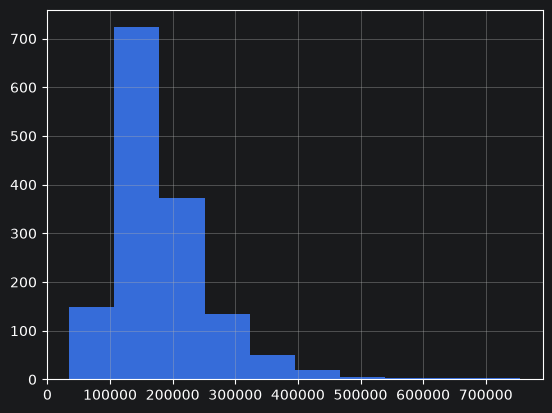

In [7]:
data['SalePrice'].hist()

<Axes: >

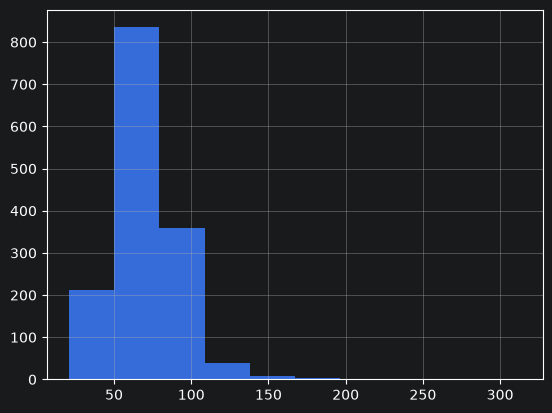

In [8]:
data['LotFrontage'].hist()

In [9]:
data.groupby('Neighborhood')['LotFrontage'].median()

Neighborhood
Blmngtn    43.0
Blueste    24.0
BrDale     21.0
BrkSide    52.0
ClearCr    80.0
CollgCr    70.0
Crawfor    74.0
Edwards    65.5
Gilbert    65.0
IDOTRR     60.0
MeadowV    21.0
Mitchel    73.0
NAmes      73.0
NPkVill    24.0
NWAmes     80.0
NoRidge    91.0
NridgHt    88.5
OldTown    60.0
SWISU      60.0
Sawyer     71.0
SawyerW    66.5
Somerst    73.5
StoneBr    61.5
Timber     85.0
Veenker    68.0
Name: LotFrontage, dtype: float64

In [10]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NoAlley,Reg,Lvl,AllPub,...,0,False,NoFence,False,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NoAlley,Reg,Lvl,AllPub,...,0,False,NoFence,False,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NoAlley,IR1,Lvl,AllPub,...,0,False,NoFence,False,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NoAlley,IR1,Lvl,AllPub,...,0,False,NoFence,False,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NoAlley,IR1,Lvl,AllPub,...,0,False,NoFence,False,0,12,2008,WD,Normal,250000


## Correlation Matrix with target value

In [11]:
data.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
FireplaceQu      0.520438
GarageYrBlt      0.508043
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplaces       0.466929
BsmtFinSF1       0.386420
BsmtExposure     0.374696
LotFrontage      0.349876
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
BsmtFinType1     0.304908
HalfBath         0.284108
GarageQual       0.273839
LotArea          0.263843
GarageCond       0.263191
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolQC           0.093708
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinType2    -0.005323
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id          

<Axes: title={'center': 'SalePrice'}, xlabel='OverallQual'>

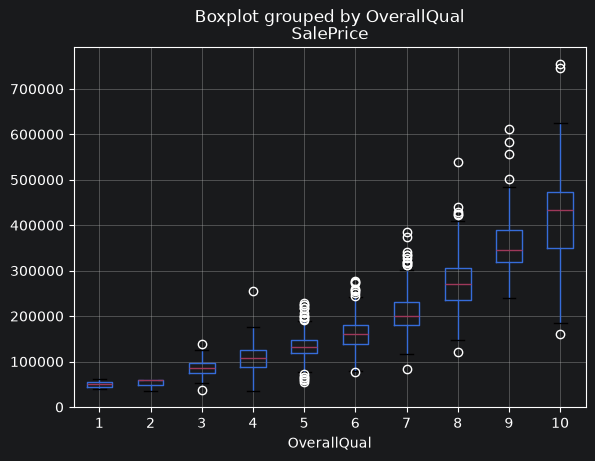

In [12]:
data.boxplot(column='SalePrice', by='OverallQual')

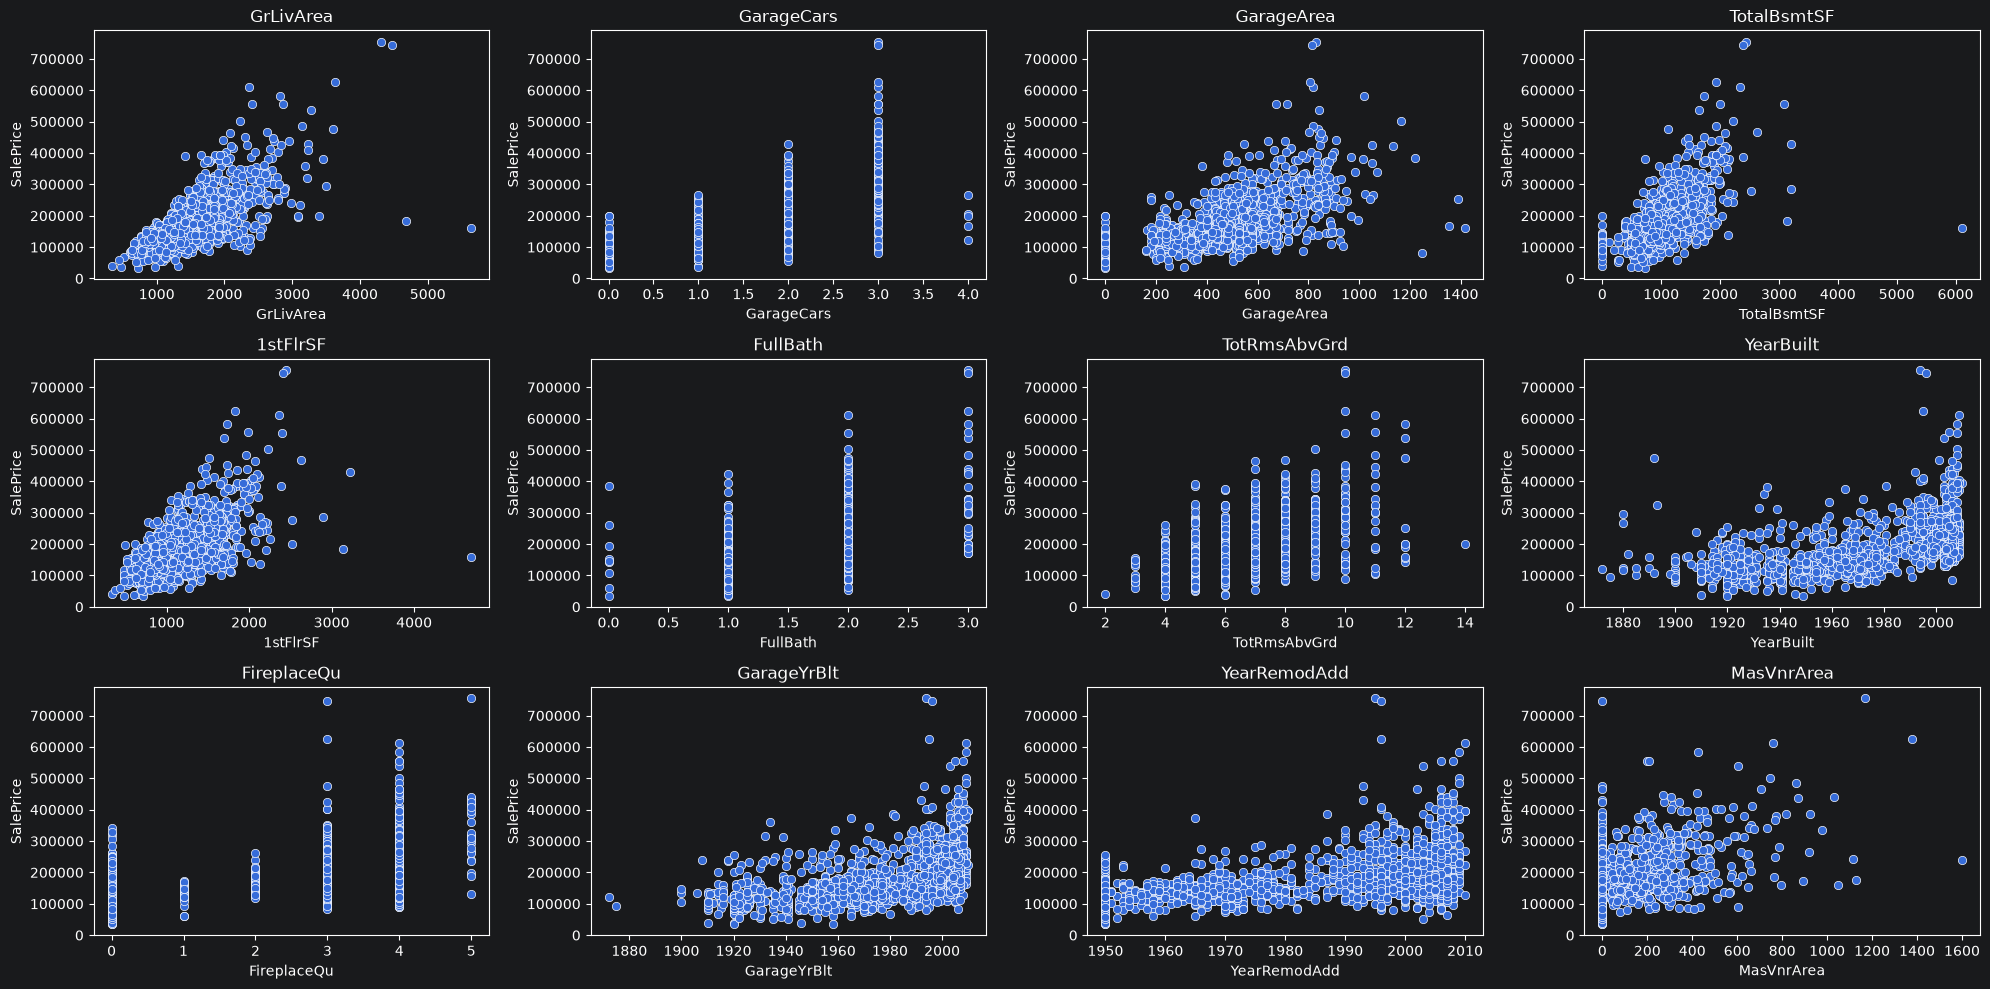

In [13]:
num_features = data.select_dtypes(include=['int64', 'float64'])

top_features = num_features.corr()['SalePrice'].sort_values(ascending=False)[2:14]

fig, axes = plt.subplots(3, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(top_features.index):
    sns.scatterplot(data=data, x=col, y='SalePrice', ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [14]:
outliers = data[(data['GrLivArea'] > 4000) & (data['SalePrice'] < 200000)]
print(outliers)

data.loc[outliers.index]

        Id  MSSubClass MSZoning  LotFrontage  LotArea Street    Alley  \
523    524          60       RL        130.0    40094   Pave  NoAlley   
1298  1299          60       RL        313.0    63887   Pave  NoAlley   

     LotShape LandContour Utilities  ... PoolArea PoolQC    Fence MiscFeature  \
523       IR1         Bnk    AllPub  ...        0  False  NoFence       False   
1298      IR3         Bnk    AllPub  ...      480   True  NoFence       False   

     MiscVal MoSold YrSold  SaleType  SaleCondition  SalePrice  
523        0     10   2007       New        Partial     184750  
1298       0      1   2008       New        Partial     160000  

[2 rows x 81 columns]


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,NoAlley,IR1,Bnk,AllPub,...,0,False,NoFence,False,0,10,2007,New,Partial,184750
1298,1299,60,RL,313.0,63887,Pave,NoAlley,IR3,Bnk,AllPub,...,480,True,NoFence,False,0,1,2008,New,Partial,160000


In [15]:
data.groupby('GarageCars')['SalePrice'].agg(['mean', 'median', 'count'])

,mean,median,count
GarageCars,,,
0,103317.283951,100000.0,81
1,128116.688347,128000.0,369
2,183851.663835,177750.0,824
3,309636.121547,295000.0,181
4,192655.800000,200000.0,5


In [16]:
data.groupby('Fireplaces')['SalePrice'].agg(['mean', 'median', 'count'])

,mean,median,count
Fireplaces,,,
0,141331.482609,135000.0,690
1,211843.909231,189975.0,650
2,240588.539130,206900.0,115
3,252000.000000,205000.0,5


In [17]:
data.groupby('TotRmsAbvGrd')['SalePrice'].agg(['mean', 'median', 'count'])

,mean,median,count
TotRmsAbvGrd,,,
2,39300.000000,39300.0,1
3,111217.647059,100000.0,17
4,122844.628866,120500.0,97
5,141550.749091,130250.0,275
6,161303.296020,155000.0,402
7,196666.784195,184100.0,329
8,213427.529412,200000.0,187
9,252988.173333,252000.0,75
10,296279.170213,285000.0,47


In [18]:
bins = range(data['YearBuilt'].min(), data['YearBuilt'].max() + 10, 10)
data['YearBuilt_decade'] = pd.cut(data['YearBuilt'], bins=bins)
data.groupby('YearBuilt_decade')['SalePrice'].agg(['mean', 'median', 'count'])

,mean,median,count
YearBuilt_decade,,,
"(1872, 1882]",177413.166667,146000.0,6
"(1882, 1892]",181566.666667,123700.0,6
"(1892, 1902]",129660.500000,106125.0,12
"(1902, 1912]",123623.230769,123750.0,26
"(1912, 1922]",127677.061728,125500.0,81
"(1922, 1932]",131622.000000,119500.0,72
"(1932, 1942]",138374.585714,123000.0,70
"(1942, 1952]",125907.053333,125000.0,75
"(1952, 1962]",145576.553763,139750.0,186


In [19]:
bins = range(data['YearRemodAdd'].min(), data['YearRemodAdd'].max() + 10, 10)
data['YearRemodAdd'] = pd.cut(data['YearRemodAdd'], bins=bins)
data.groupby('YearRemodAdd')['SalePrice'].agg(['mean', 'median', 'count'])

,mean,median,count
YearRemodAdd,,,
"(1950, 1960]",131306.443396,133100.0,106
"(1960, 1970]",145299.610738,139950.0,149
"(1970, 1980]",149442.773585,146800.0,159
"(1980, 1990]",183180.581395,175000.0,86
"(1990, 2000]",202562.077193,181000.0,285
"(2000, 2010]",222179.625755,205000.0,497


In [20]:
bins = range(int(data['GarageYrBlt'].min()), int(data['GarageYrBlt'].max()) + 10, 10)
data['GarageYrBlt'] = pd.cut(data['GarageYrBlt'], bins=bins)
data.groupby('GarageYrBlt')['SalePrice'].agg(['mean', 'median', 'count'])

,mean,median,count
GarageYrBlt,,,
"(1872, 1882]",94000.000000,94000.0,1
"(1892, 1902]",128683.333333,133900.0,3
"(1902, 1912]",117523.076923,107500.0,13
"(1912, 1922]",120724.729167,114000.0,48
"(1922, 1932]",136523.153846,125000.0,52
"(1932, 1942]",135087.704918,119750.0,61
"(1942, 1952]",131566.132353,126250.0,68
"(1952, 1962]",141906.346369,137500.0,179
"(1962, 1972]",148543.736842,143000.0,190


## Hypothesis
 - `SalePrice` Right skewness - logarithm transformation for target feature.

### Linear Features (`OverallQual`, `GrLivArea`, `TotalBsmtSF`, `stFlrSF`)
 - The highest correlation feature with `SalePrice` is `OverallQual`. It is linear relation because medians rise gradually. Most of the outliers are located in the 5-9 groups. Prices of higher-value houses are more widely dispersed.
 - The growing spread of `SalePrice` in higher OverallQual groups may lead to larger prediction errors for high-quality houses. This should be verified through residual/error analysis after training a first model.
 - Houses `524` and `1299` break the general linear trend between `GrLivArea` and
  `SalePrice` — both have `GrLivArea` > 4000 but `SalePrice` < 200000. House `1299`
  is additionally unusual in `TotalBsmtSF` (> 6000) and `1stFlrSF` (> 4000), both
  paired with the same low `SalePrice`.
- The dataset's creator (Dean De Cock) explicitly recommends removing houses with
  `GrLivArea` > 4000, since these are known extreme outliers rather than a real
  market pattern.
- Consequence for model: these two rows will be removed from the training data
  before fitting a model, since keeping them could distort a linear model's
  coefficients.
### Discrete Features (`GarageCars`, `FullBath`, `TotRmsAbvGrd`)
- Observation: `SalePrice` generally rises with `GarageCars`, `FullBath`, `TotRmsAbvGrd`,
  and `Fireplaces`, matching the pattern already seen with `OverallQual`. However, the
  highest-value groups often contain very few observations (GarageCars=4: n=5,
  Fireplaces=3: n=5, TotRmsAbvGrd=2: n=1), making their mean/median unreliable.
- Interpretation: These extreme values are naturally rare in a residential housing
  market (few houses have 4 garages or only 2 total rooms), so any statistic
  computed on such a small sample is dominated by one or two individual houses
  rather than reflecting a real, generalizable trend.
- Consequence for model: These sparse categories will be merged with their
  neighboring value during feature engineering (e.g. `GarageCars` 3 and 4 combined
  into "3+").
## Non-linear Features (YearBuilt, YearRemodAdd, GarageYrBlt)
- Observation: SalePrice rises with YearBuilt, but not at a constant rate. The
  earliest decades (before ~1902) have very few observations (n=6-12) and are
  unreliable. From the 1950s onward (n=186+), the median price increase between
  decades grows through the 1980s-1990s, then slows down slightly in the 2000s.
  YearRemodAdd shows a cleaner, steadily rising trend across all decades, with no
  small-sample groups (all n>=86). GarageYrBlt matches YearBuilt in 1089/1379
  (79%) of non-missing rows, meaning about 21% of garages were built in a
  different year than the house itself.
- Interpretation: Houses are rarely torn down and rebuilt, so very old houses
  sold in 2006-2010 are naturally scarce in this dataset, explaining the small,
  unreliable early decades. The slowdown in price growth after the 1990s suggests
  the relationship with year is not simply linear, but has a peak growth period.
  The GarageYrBlt mismatch rate confirms it carries real, independent information
  rather than duplicating YearBuilt.
- Consequence for model: The sparse early decades in YearBuilt and GarageYrBlt
  will be merged into a single "before 1902" bucket if these features are binned,
  the same approach used for the discrete/ordinal features above. All three
  year-based features will be kept for modeling, since none of them duplicate
  one another.